In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn import tree
from sklearn.model_selection import GridSearchCV

In [3]:
data = pd.read_csv('Titanic-Dataset.csv')

In [4]:
X = data.drop(columns=['Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

numeric_features = ['Age', 'Fare']
X_train[numeric_features] = X_train[numeric_features].fillna(X_train[numeric_features].median())
X_test[numeric_features] = X_test[numeric_features].fillna(X_test[numeric_features].median())

sc = StandardScaler()
X_train[numeric_features] = sc.fit_transform(X_train[numeric_features])
X_test[numeric_features] = sc.transform(X_test[numeric_features])

categorical_features = ['Sex', 'Embarked']
X_train[categorical_features] = X_train[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])
X_test[categorical_features] = X_test[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])

X_train = pd.get_dummies(X_train, columns = categorical_features, dtype=int, drop_first = True)
X_test = pd.get_dummies(X_test, columns = categorical_features, dtype=int, drop_first = True)

X_train.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket'], inplace = True)
X_test.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket'], inplace = True)

In [7]:
#Train a Decision Tree with no max_depth limit — watch it overfit
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = tree.DecisionTreeClassifier()
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Cross-validation accuracy scores: {scores}')
print(f'Average Accuracy: {np.mean(scores):.4f}')

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")


train_accuracy = model.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Cross-validation accuracy scores: [0.80263158 0.74342105 0.74172185 0.7615894  0.77483444]
Average Accuracy: 0.7648
Test set accuracy: 0.7687
Train set accuracy: 0.9762
Precision score is 0.6811594202898551
Recall score is 0.8392857142857143
F1 Score is 0.752


In [9]:
#Q2) Train again with max_depth=3 — compare train vs val accuracy

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = tree.DecisionTreeClassifier(max_depth = 3)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Cross-validation accuracy scores: {scores}')
print(f'Average Accuracy: {np.mean(scores):.4f}')

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")


train_accuracy = model.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Cross-validation accuracy scores: [0.82894737 0.80263158 0.7615894  0.84768212 0.80794702]
Average Accuracy: 0.8098
Test set accuracy: 0.8134
Train set accuracy: 0.8230
Precision score is 0.8163265306122449
Recall score is 0.7142857142857143
F1 Score is 0.7619047619047619


In [20]:
#Q3) Train Random Forest — compare to both

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Cross-validation accuracy scores: {scores}')
print(f'Average Accuracy: {np.mean(scores):.4f}')

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")


train_accuracy = model.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Cross-validation accuracy scores: [0.83552632 0.80921053 0.8013245  0.76821192 0.8013245 ]
Average Accuracy: 0.8031
Test set accuracy: 0.8060
Train set accuracy: 0.9762
Precision score is 0.7678571428571429
Recall score is 0.7678571428571429
F1 Score is 0.7678571428571429


In [21]:
#Q3) Train Random Forest — compare to both

kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth = 3)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Cross-validation accuracy scores: {scores}')
print(f'Average Accuracy: {np.mean(scores):.4f}')

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")


train_accuracy = model.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Cross-validation accuracy scores: [0.80921053 0.77631579 0.78145695 0.87417219 0.79470199]
Average Accuracy: 0.8072
Test set accuracy: 0.8209
Train set accuracy: 0.8283
Precision score is 0.8636363636363636
Recall score is 0.6785714285714286
F1 Score is 0.76


<BarContainer object of 6 artists>

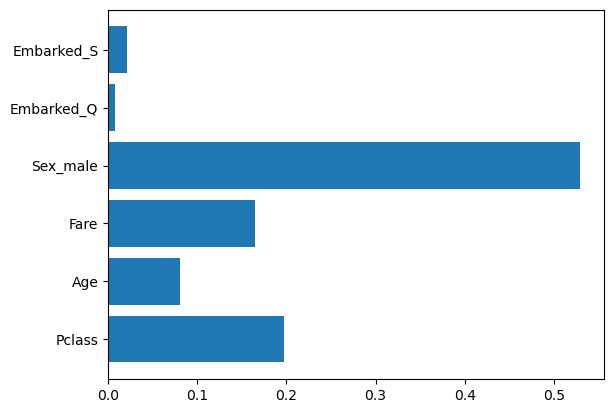

In [24]:
#Q4) Plot feature importances as a bar chart

plt.barh(X_train.columns, model.feature_importances_)

In [28]:
#Q5) Use GridSearchCV to tune max_depth and n_estimators

params = {'n_estimators' : [50, 100, 150, 200, 250],
          'max_depth' : [3, 5, 7, 9, 11]}

model = RandomForestClassifier()
gs = GridSearchCV(estimator = model, param_grid = params, cv=10)


gs.fit(X_train, y_train)
test_accuracy = gs.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")


train_accuracy = gs.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

y_pred = gs.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Test set accuracy: 0.8358
Train set accuracy: 0.8996
Precision score is 0.8541666666666666
Recall score is 0.7321428571428571
F1 Score is 0.7884615384615384


In [29]:
print(gs.best_params_, gs.best_score_)

{'max_depth': 7, 'n_estimators': 200} 0.8256491228070175
